In [8]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# ==========================================
# 1. Initialization and Setup
# ==========================================
# Load the Karate Club graph and fix the layout for consistent visualization
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=42)
m = G.number_of_edges()
global_degrees = dict(G.degree())

# Initialize tracking variables
communities = [list(G.nodes())]
metrics_history = {'degree': [], 'betweenness': [],
                   'closeness': [], 'clustering': []}
iterations_data = []

In [10]:
# ==========================================
# 2. Spectral Bisection Function
# ==========================================
def split_community(C):
    """
    Computes the restricted modularity matrix B^(C) for a community C 
    and returns a bipartition if the leading eigenvalue lambda_1 > 0.
    """
    n_C = len(C)
    if n_C <= 1:
        return None

    B_C = np.zeros((n_C, n_C))
    
# Construct restricted modularity matrix
    for i, u in enumerate(C):
        for j, v in enumerate(C):
            A_ij = 1 if G.has_edge(u, v) else 0
            B_C[i, j] = A_ij - (global_degrees[u] *
                                global_degrees[v]) / (2 * m)
            
# Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(B_C)

    # np.linalg.eigh sorts in ascending order; leading eigenpair is at the end
    lambda_1 = eigenvalues[-1]
    u_1 = eigenvectors[:, -1]

    # Eigenvalue stopping criterion
    if lambda_1 > 1e-5:
        C_pos = [C[i] for i in range(n_C) if u_1[i] > 0]
        C_neg = [C[i] for i in range(n_C) if u_1[i] <= 0]
        # Only accept the split if both partitions contain at least one node
        if len(C_pos) > 0 and len(C_neg) > 0:
            return C_pos, C_neg

    return None


def get_fractured_graph(current_communities):
    """Creates a subgraph containing only intra-community edges to compute accurate metrics."""
    G_fractured = nx.Graph()
    G_fractured.add_nodes_from(G.nodes())
    for comm in current_communities:
        G_fractured.add_edges_from(G.subgraph(comm).edges())
    return G_fractured


def record_metrics(G_current):
    """Computes and stores standard centrality and cohesion measures."""
    metrics_history['degree'].append(nx.degree_centrality(G_current))
    metrics_history['betweenness'].append(nx.betweenness_centrality(G_current))
    metrics_history['closeness'].append(nx.closeness_centrality(G_current))
    metrics_history['clustering'].append(nx.clustering(G_current))

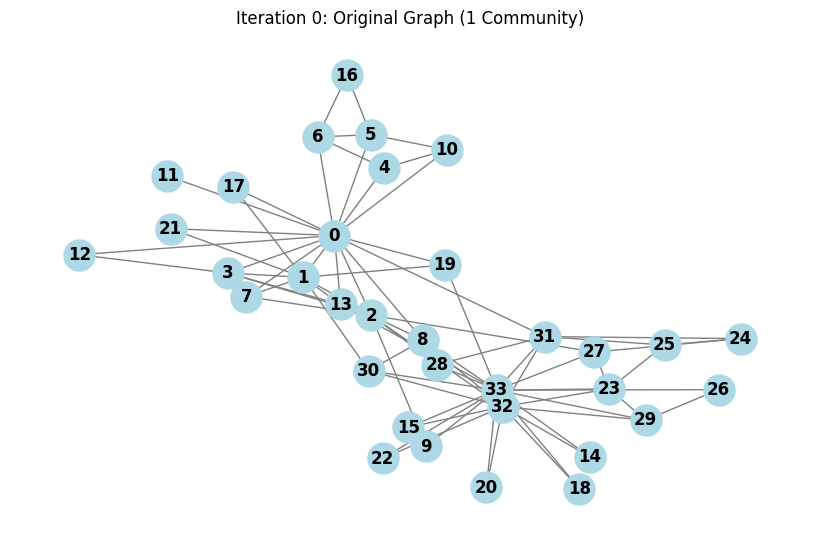

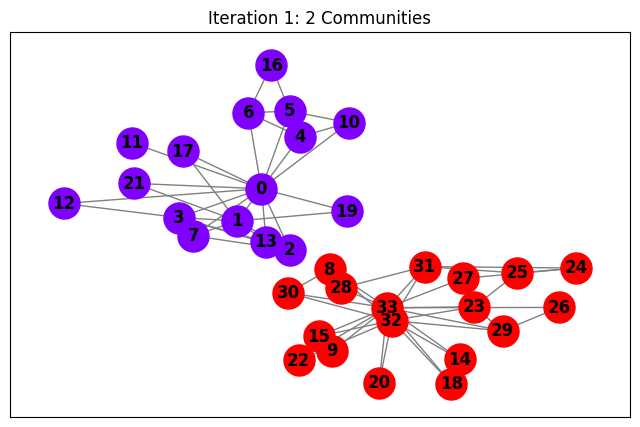

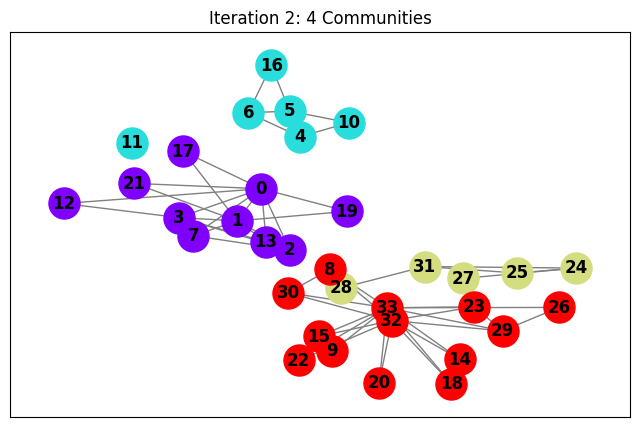

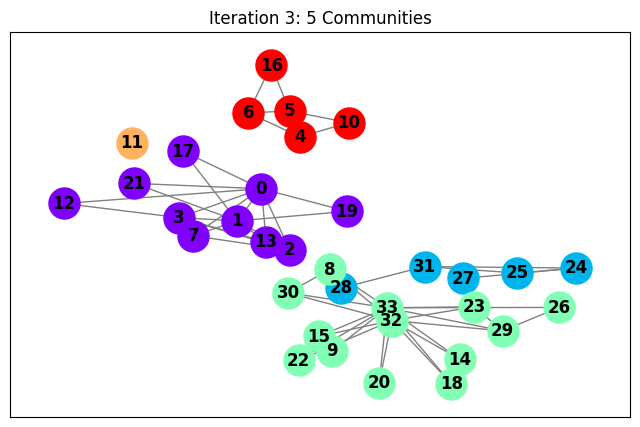

In [11]:
# ==========================================
# 3. Recursive Partitioning Loop
# ==========================================
iteration = 0
active_communities = communities.copy()
final_communities = []

# Record and plot Initial State (Iteration 0)
G_current = get_fractured_graph(active_communities)
record_metrics(G_current)

plt.figure(figsize=(8, 5))
nx.draw(G_current, pos, with_labels=True, node_color='lightblue',
        edge_color='gray', node_size=500, font_weight='bold')
plt.title(f"Iteration 0: Original Graph (1 Community)")
plt.show()

# Perform BFS-style recursive splits
while active_communities:
    iteration += 1
    next_communities = []
    split_occurred = False

    for comm in active_communities:
        split_result = split_community(comm)
        if split_result:
            next_communities.extend(split_result)
            split_occurred = True
        else:
            final_communities.append(comm)

    if not split_occurred:
        break

    active_communities = next_communities
    current_partition = final_communities + active_communities

    # Build graph with severed inter-community edges for metric calculation
    G_current = get_fractured_graph(current_partition)
    record_metrics(G_current)

    # Visualizing the split
    plt.figure(figsize=(8, 5))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(current_partition)))

    for idx, comm in enumerate(current_partition):
        nx.draw_networkx_nodes(G_current, pos, nodelist=comm,
                               node_color=[colors[idx]], node_size=500)

    nx.draw_networkx_edges(G_current, pos, edge_color='gray')
    nx.draw_networkx_labels(G_current, pos, font_weight='bold')
    plt.title(f"Iteration {iteration}: {len(current_partition)} Communities")
    plt.show()

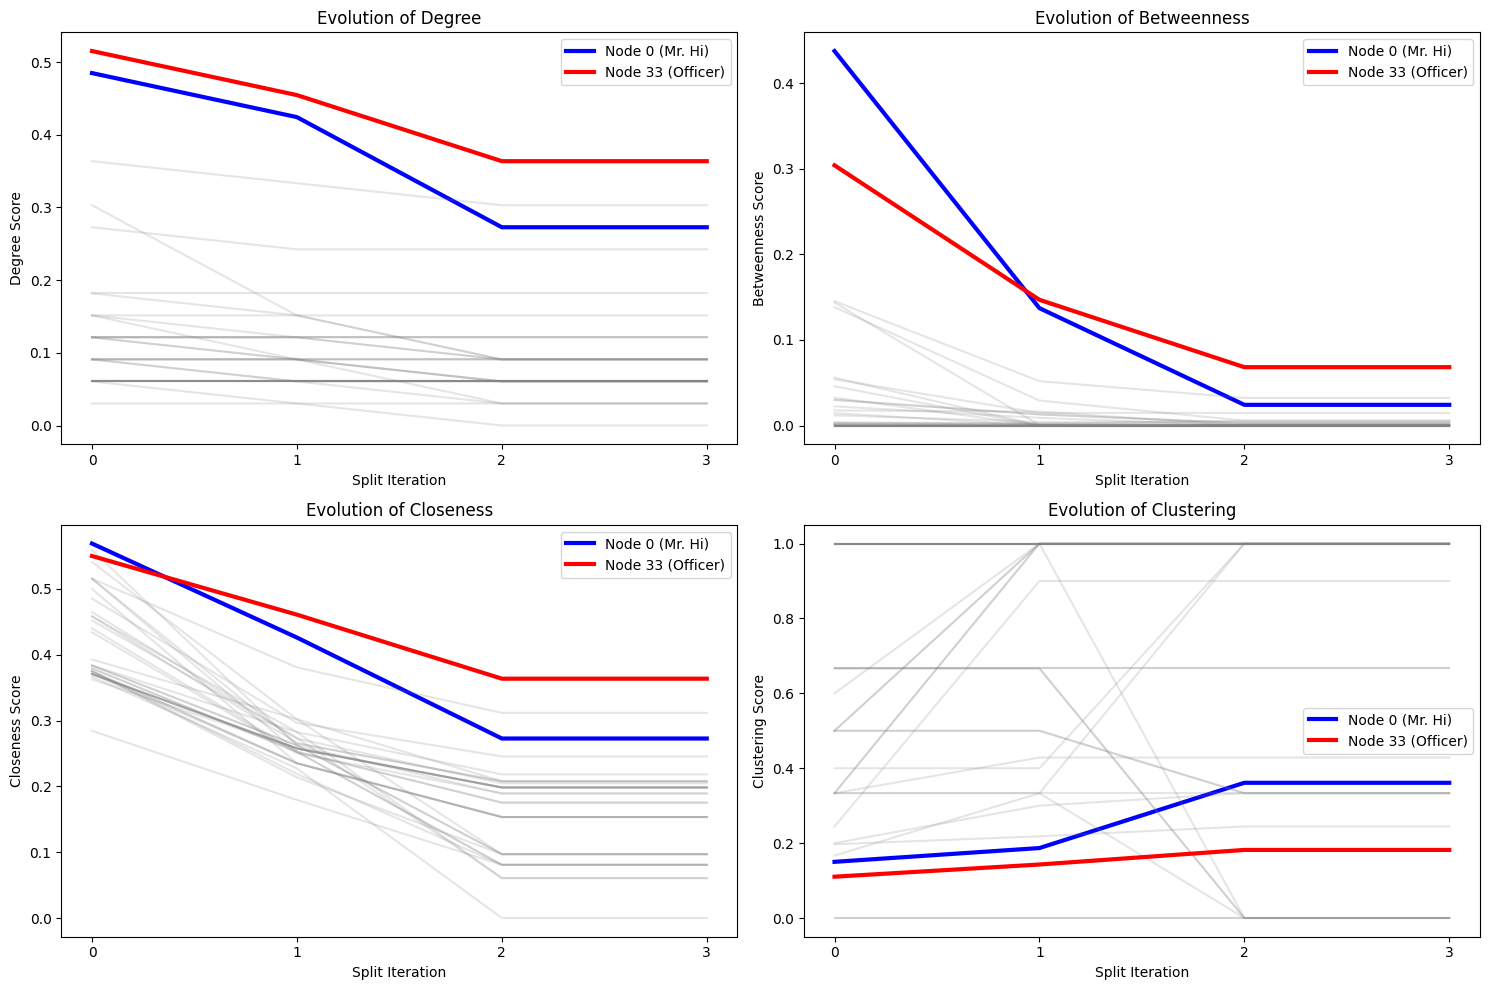

In [12]:
# ==========================================
# 4. Plotting Metric Evolution
# ==========================================
metrics_names = ['degree', 'betweenness', 'closeness', 'clustering']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_names):
    ax = axes[idx]
    # Restructure data to plot lines per node across iterations
    node_data = {node: [iter_dict[node] for iter_dict in metrics_history[metric]]
                 for node in G.nodes()}

    for node, values in node_data.items():
        # Highlight the main faction leaders: Mr. Hi (0) and Officer (33)
        if node == 0:
            ax.plot(values, label='Node 0 (Mr. Hi)', linewidth=3, color='blue')
        elif node == 33:
            ax.plot(values, label='Node 33 (Officer)',
                    linewidth=3, color='red')
        else:
            ax.plot(values, alpha=0.2, color='gray')

    ax.set_title(f"Evolution of {metric.capitalize()}")
    ax.set_xlabel("Split Iteration")
    ax.set_ylabel(metric.capitalize() + " Score")
    ax.set_xticks(range(len(metrics_history[metric])))
    ax.legend()

plt.tight_layout()
plt.show()